In [30]:
# --- en la primera celda del notebook
%load_ext autoreload
%autoreload 2

from scripts import helpers as hp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
#ruta = r'09 features/redes_local/datos/data/'
ruta = r'08 Clasificacion de Movimientos Artisticos/bigbigbang/'

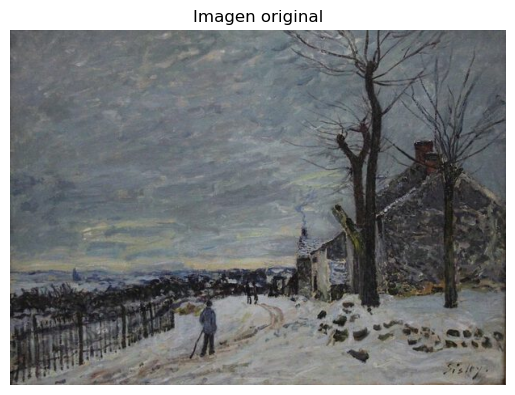

In [32]:
imagen = hp.Leer_Imagen(ruta, "Alfred_Sisley_1.jpg")
hp.Visualizar_Imagen(imagen)

In [33]:
# Pintor -> género (según tu tabla)
painter_to_genre = {
    "Joan_Miro": "Surrealismo",
    "Salvador_Dali": "Surrealismo",
    "Rene_Magritte": "Surrealismo",
    "Pablo_Picasso": "Cubismo",
    "Jackson_Pollock": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille_Pissarro": "Impresionismo",
    "Alfred_Sisley": "Impresionismo",
    "Claude_Monet": "Impresionismo",
    "Vincent_van_Gogh": "Impresionismo",
}

# Género -> etiqueta numérica
genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}


In [34]:
import os

def get_painter_from_filename(path: str) -> str:
    """
    'datos/data/Alfred_Sisley_1.jpg' -> 'Alfred_Sisley'
    """
    fname = os.path.basename(path)          # Alfred_Sisley_1.jpg
    stem = os.path.splitext(fname)[0]       # Alfred_Sisley_1
    parts = stem.split("_")                 # ['Alfred', 'Sisley', '1']
    painter = "_".join(parts[:-1])          # 'Alfred_Sisley'
    return painter


In [35]:
import glob
import cv2
import numpy as np
import pandas as pd


In [37]:

DATA_DIR = ruta   # ajusta si tu ruta es distinta

rows = []

for img_path in glob.glob(os.path.join(DATA_DIR, "*.jpg")):
    painter = get_painter_from_filename(img_path)

    # Saltar archivos raros que no estén en el diccionario
    if painter not in painter_to_genre:
        print(f"Aviso: pintor '{painter}' no está en el diccionario, se omite.")
        continue

    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    # Leer imagen con OpenCV (BGR) y convertir a RGB
    bgr = cv2.imread(img_path)
    if bgr is None:
        print(f"Aviso: no se pudo leer {img_path}, se omite.")
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # === AQUÍ llamas a tu súper función de 59 features ===
    feats = hp.extraer_caracteristicas(rgb)  # dict con tus 59 features

    # Agregar metadatos útiles
    feats["filename"] = os.path.basename(img_path)
    feats["painter"] = painter
    feats["genre"] = genre
    feats["label"] = label

    rows.append(feats)

# Crear DataFrame final
df = pd.DataFrame(rows)
print(df.shape)   # deberías ver (200, 59 + 4 columnas extra aprox.)
df.head()


(750, 78)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,lbp_hist_15,lbp_entropy,brightness_skew,ratio_dark,ratio_bright,ratio_warm,filename,painter,genre,label
0,113.894936,127.379158,103.346657,53.270428,70.752464,75.454781,0.0,2.0,0.0,255.0,...,0.010568,0.319275,0.098742,0.325457,0.383843,0.502599,Alfred_Sisley_001.jpg,Alfred_Sisley,Impresionismo,4
1,100.800140,91.574242,75.356453,76.134636,75.270805,72.747894,5.0,8.0,0.0,255.0,...,0.014187,0.315325,0.939020,0.533068,0.197477,0.872667,Alfred_Sisley_002.jpg,Alfred_Sisley,Impresionismo,4
2,129.785233,116.044861,89.187218,47.168243,54.259525,42.555046,49.0,28.0,20.0,255.0,...,0.012098,0.320461,0.504830,0.110174,0.221088,0.882166,Alfred_Sisley_003.jpg,Alfred_Sisley,Impresionismo,4
3,119.764275,126.478325,115.545212,55.139767,62.966022,80.313644,10.0,1.0,0.0,255.0,...,0.011071,0.320051,0.354163,0.230577,0.352576,0.416563,Alfred_Sisley_004.jpg,Alfred_Sisley,Impresionismo,4
4,143.549225,138.841385,130.065567,87.223038,88.330170,91.912506,3.0,7.0,0.0,255.0,...,0.014276,0.323042,-0.238437,0.321144,0.475187,0.469545,Alfred_Sisley_005.jpg,Alfred_Sisley,Impresionismo,4


In [38]:
# este df se guarda como los datos.
df.to_csv(r'09 features/redes_local/datos/processed/df2_bb.csv', index = False)

In [ ]:
import numpy as np

# Columnas que NO son features
meta_cols = ["filename", "painter", "genre", "label"]

# Todas las columnas que consideramos features
feature_cols = [c for c in df.columns if c not in meta_cols]

# Asegurarnos de que son numéricas
X = df[feature_cols].to_numpy(dtype=np.float32)   # (n_samples, n_features)
y = df["label"].to_numpy(dtype=np.int64)          # (n_samples,)

print("Shapes X, y:", X.shape, y.shape)
print("Conteo por clase en y:", np.bincount(y))
print("Orden de features:", feature_cols)


Shapes X, y: (200, 53) (200,)
Conteo por clase en y: [50 30 15 30 75]
Orden de features: ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'min_R', 'min_G', 'min_B', 'max_R', 'max_G', 'max_B', 'mean_S', 'std_S', 'mean_V', 'std_V', 'rms', 'sobel_mean', 'sobel_std', 'sobel_pct_strong', 'laplacian_mean_abs', 'laplacian_std_abs', 'gabor_mean_abs_0', 'gabor_std_abs_0', 'gabor_mean_abs_45', 'gabor_std_abs_45', 'gabor_mean_abs_90', 'gabor_std_abs_90', 'gabor_mean_abs_135', 'gabor_std_abs_135', 'mean_block_0_0', 'pct_bright_block_0_0', 'mean_block_0_1', 'pct_bright_block_0_1', 'mean_block_0_2', 'pct_bright_block_0_2', 'mean_block_1_0', 'pct_bright_block_1_0', 'mean_block_1_1', 'pct_bright_block_1_1', 'mean_block_1_2', 'pct_bright_block_1_2', 'mean_block_2_0', 'pct_bright_block_2_0', 'mean_block_2_1', 'pct_bright_block_2_1', 'mean_block_2_2', 'pct_bright_block_2_2', 'H_shannon', 'center_mean_ratio', 'center_bright_ratio', 'lum_centroid_x', 'lum_centroid_y']


In [ ]:
from imblearn.over_sampling import SMOTE

# k_neighbors debe ser < tamaño de la clase minoritaria.
# Si tu clase más chica tiene 15 elementos, 3 está bien.
smote = SMOTE(random_state=42, k_neighbors=3)

X_over, y_over = smote.fit_resample(X, y)

print("Shapes X_over, y_over:", X_over.shape, y_over.shape)
print("Conteo por clase en y_over:", np.bincount(y_over))


Shapes X_over, y_over: (375, 53) (375,)
Conteo por clase en y_over: [75 75 75 75 75]
